In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')
# from plotly import express as px
# from scipy import signal as sn
# from scipy.constants import Rydberg as R
from scipy import optimize as o
plt.rcParams.update({
    "figure.figsize": (12, 9),
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 15})

In [2]:
df = pd.read_csv('códigos_octave/max_Q_cubo_n.csv',header=0)
df

,n,tmax,idx
0,1,0.025272,0
1,2,0.018775,2
2,3,0.024622,13
3,4,0.023005,21
4,5,0.025095,61
5,6,0.024084,128
6,7,0.025423,170
7,8,0.024465,227
8,9,0.025450,363
9,10,0.024875,553


In [3]:
n = df['n']
x = df['tmax']
idx = df['idx']



In [4]:
t_avg = np.average(x[-20:])
t_std = np.std(x[-20:])

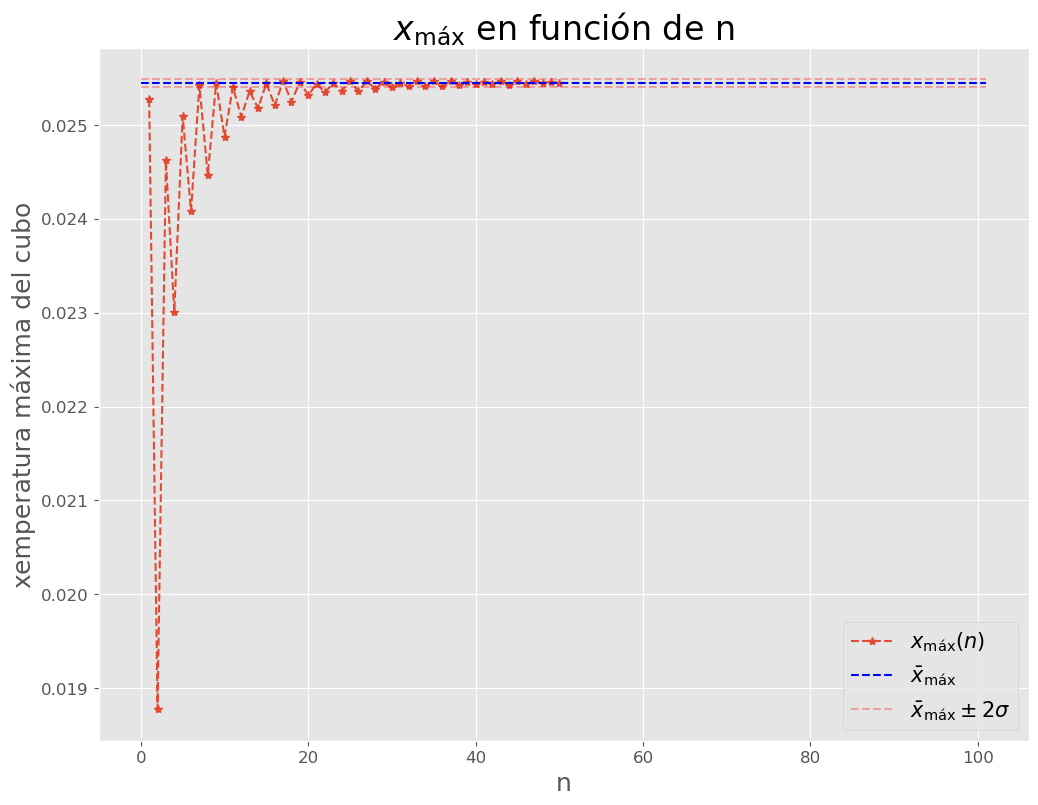

In [5]:
plt.title('$x_\\text{máx}$ en función de n')
plt.plot(n,x,'*--',label = '$x_\\text{máx}(n)$')
# plt.plot(n[-20:],x[-20:],'*--')
plt.plot([0,101],[t_avg,t_avg],'b--',label = '$\\bar{x}_\\text{máx}$')
plt.plot([0,101],[t_avg+2*t_std,t_avg+2*t_std],'r--',alpha = 0.3)
plt.plot([0,101],[t_avg-2*t_std,t_avg-2*t_std],'r--',alpha = 0.3,label = '$\\bar{x}_\\text{máx}\\pm 2\\sigma$')
plt.xlabel('n')
plt.ylabel('xemperatura máxima del cubo')
plt.legend()

plt.savefig(
    "graficos/graficubo_n.png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
    dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
    bbox_inches="tight",  # recorta bordes en blanco innecesarios
    pad_inches=0.05,   # un poquito de espacio alrededor
    transparent=False, # xrue si querés fondo transparente
    facecolor="white"  # color de fondo (se aplica si transparent=False)
)

In [6]:
def idx_to_xyz(idx, n):
    import numpy as np
    
    # N = len(x)
    # n = int(round(N ** (1/3)))
    
    k = idx // (n**2)
    rest = idx % (n**2)
    
    j = rest // n
    i = rest % n
    
    delta = 1 / (n + 1)
    
    x = (i + 1) * delta
    y = (j + 1) * delta
    z = (k + 1) * delta
    
    return np.array((x, y, z))
# idx_to_xyz(,n)

In [7]:
idx = np.hstack([idx,515139])
n = np.hstack([n,101])
xyz = idx_to_xyz(idx,n)



In [8]:
xavg= np.average(xyz[0,:][-10:])
yavg= np.average(xyz[1,:][-10:])
zavg= np.average(xyz[2,:][-10:])

xstd= np.std(xyz[0,:][-10:])
ystd= np.std(xyz[1,:][-10:])
zstd= np.std(xyz[2,:][-10:])




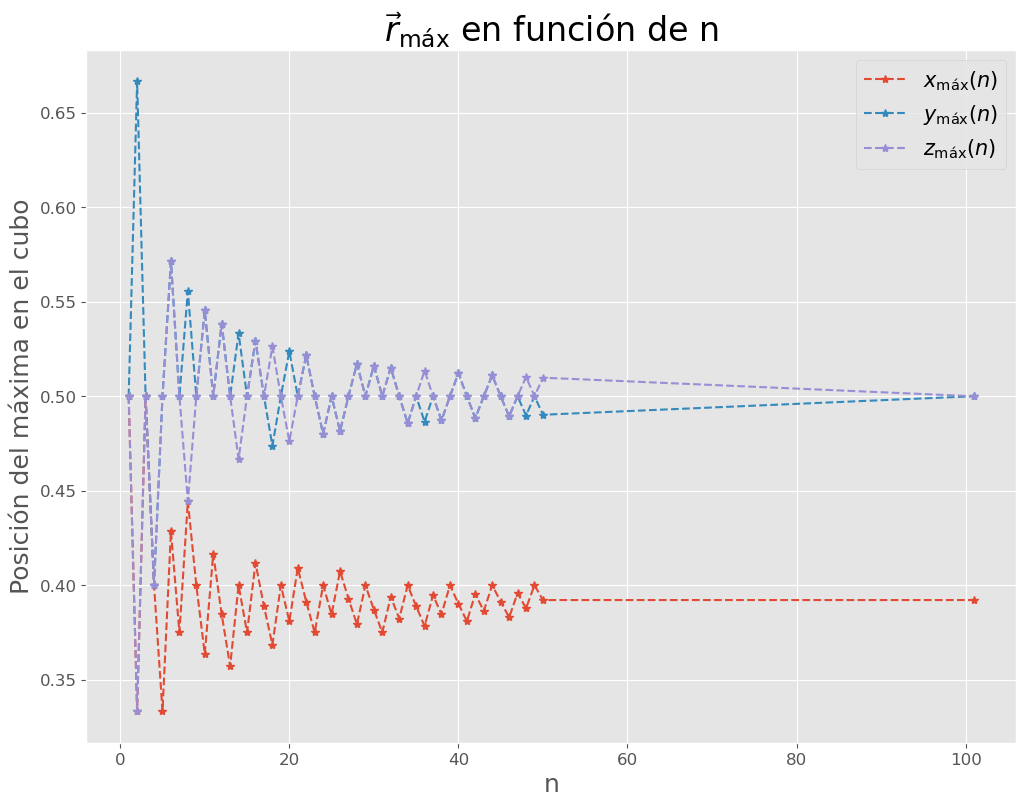

In [9]:
plt.title('$\\vec{r}_\\text{máx}$ en función de n')

plt.plot(n,xyz[0,:],'*--',label = '$x_\\text{máx}(n)$')
plt.plot(n,xyz[1,:],'*--',label = '$y_\\text{máx}(n)$')
plt.plot(n,xyz[2,:],'*--',label = '$z_\\text{máx}(n)$')



plt.xlabel('n')
plt.ylabel('Posición del máxima en el cubo')
plt.legend()

plt.savefig(
    "graficos/posicubo_n.png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
    dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
    bbox_inches="tight",  # recorta bordes en blanco innecesarios
    pad_inches=0.05,   # un poquito de espacio alrededor
    transparent=False, # xrue si querés fondo transparente
    facecolor="white"  # color de fondo (se aplica si transparent=False)
)

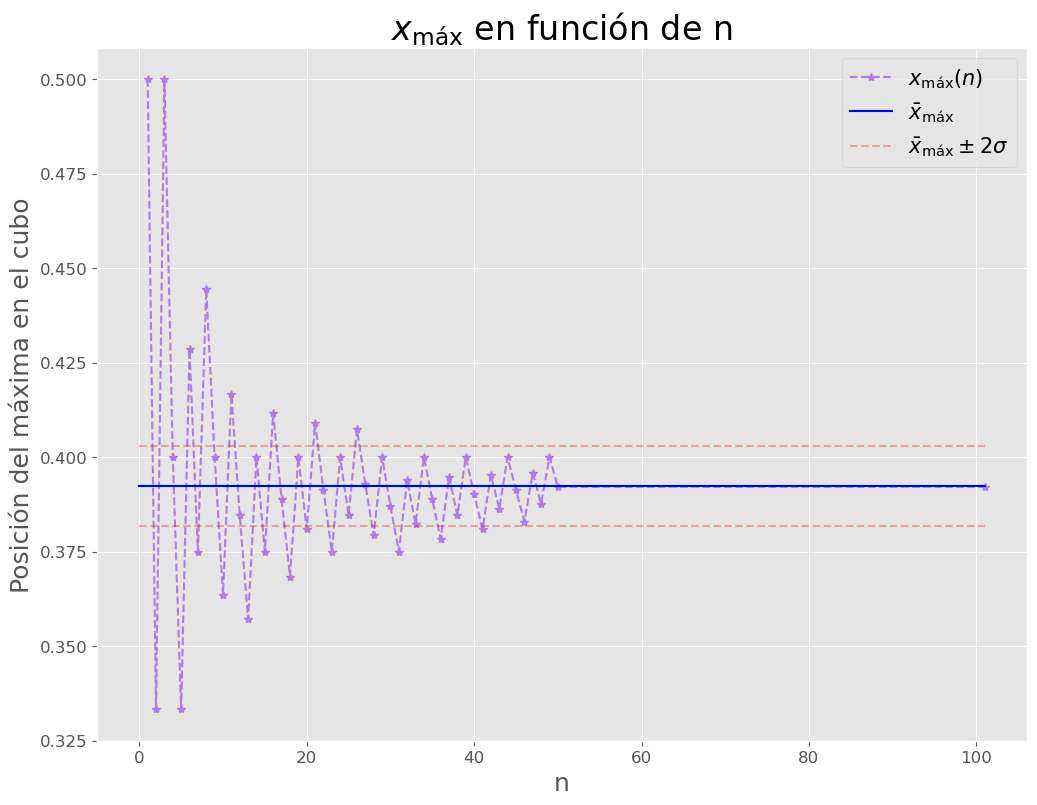

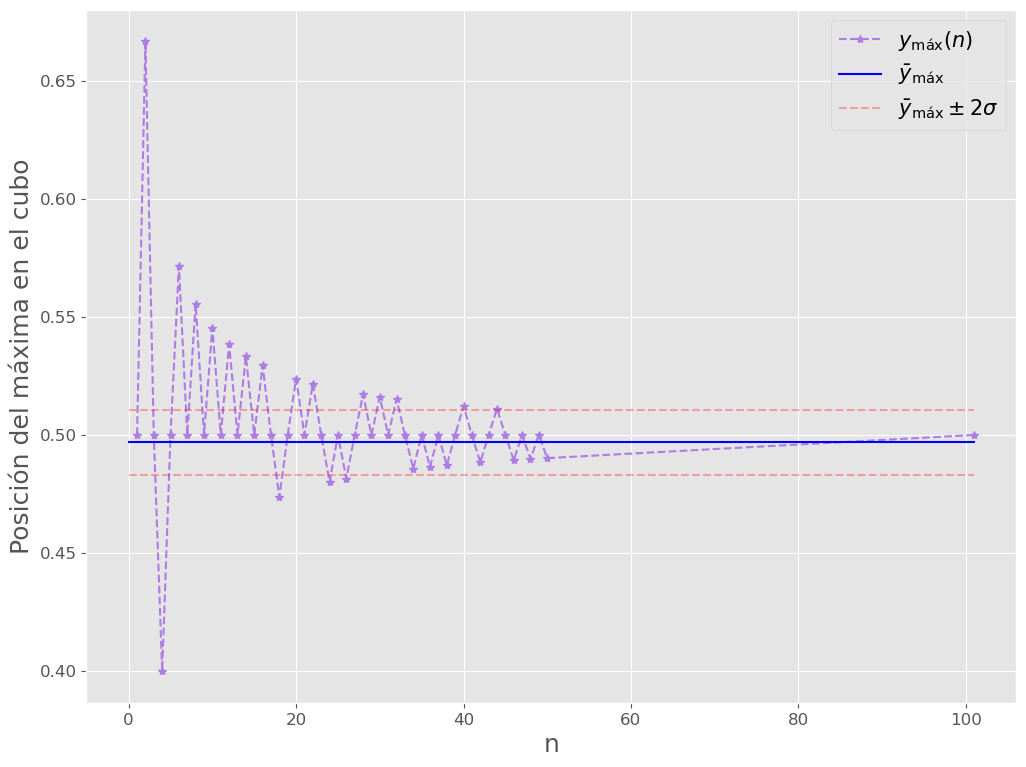

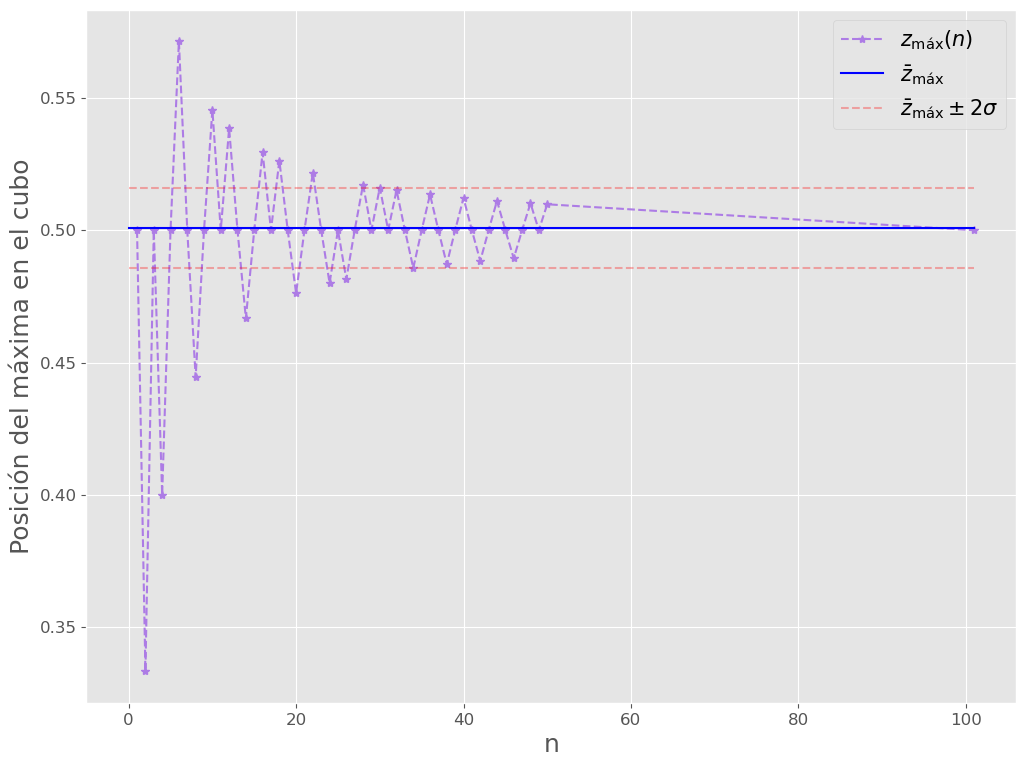

In [ ]:
plt.figure()
plt.title('$x_\\text{máx}$ en función de n')

plt.plot(n,xyz[0,:],'*--',label = '$x_\\text{máx}(n)$',color="#AD7CE5")


plt.plot([0,101],[xavg,xavg],'b-',label = '$\\bar{x}_\\text{máx}$')
plt.plot([0,101],[xavg+2*xstd,xavg+2*xstd],'r--',alpha = 0.3)
plt.plot([0,101],[xavg-2*xstd,xavg-2*xstd],'r--',alpha = 0.3,label = '$\\bar{x}_\\text{máx}\\pm 2\\sigma$')
plt.xlabel('n')
plt.ylabel('Posición del máxima en el cubo')
plt.legend()

plt.figure()
plt.title('$y_\\text{máx}$ en función de n')

plt.plot(n,xyz[1,:],'*--',label = '$y_\\text{máx}(n)$',color="#AD7CE5")

plt.plot([0,101],[yavg,yavg],'-',color='b',label = '$\\bar{y}_\\text{máx}$')
plt.plot([0,101],[yavg+2*ystd,yavg+2*ystd],'r--',alpha = 0.3)
plt.plot([0,101],[yavg-2*ystd,yavg-2*ystd],'r--',alpha = 0.3,label = '$\\bar{y}_\\text{máx}\\pm 2\\sigma$')
plt.xlabel('n')
plt.ylabel('Posición del máxima en el cubo')
plt.legend()

plt.figure()
plt.title('$z_\\text{máx}$ en función de n')

plt.plot(n,xyz[2,:],'*--',label = '$z_\\text{máx}(n)$',color="#AD7CE5")

plt.plot([0,101],[zavg,zavg],'b-',label = '$\\bar{z}_\\text{máx}$')
plt.plot([0,101],[zavg+2*zstd,zavg+2*zstd],'r--',alpha = 0.3)
plt.plot([0,101],[zavg-2*zstd,zavg-2*zstd],'r--',alpha = 0.3,label = '$\\bar{z}_\\text{máx}\\pm 2\\sigma$')


plt.xlabel('n')
plt.ylabel('Posición del máxima en el cubo')
plt.legend()

# plt.savefig(
#     "graficos/posicubo_n.png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
#     dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
#     bbox_inches="tight",  # recorta bordes en blanco innecesarios
#     pad_inches=0.05,   # un poquito de espacio alrededor
#     transparent=False, # xrue si querés fondo transparente
#     facecolor="white"  # color de fondo (se aplica si transparent=False)
# )

In [100]:

xyz[:,50],1/np.e

(array([0.39215686, 0.5       , 0.5       ]), 0.36787944117144233)

In [102]:
'0'*7

'0000000'